<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/09_classifiers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (1 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [7]:
# WRITE YOUR CODE HERE

library(tidyverse)

lexdata <- read_csv("/Users/Ali/Documents/GitHub/DataSciencePsychNeuro/Exercise datasets/lexDat/LexicalData_withIncorrect.csv")
items <- read_csv("/Users/Ali/Documents/GitHub/DataSciencePsychNeuro/Exercise datasets/lexDat/Items.csv")

df <- lexdata %>%
  left_join(items %>% 
              select(Word, Length, Log_Freq_HAL),
            by = c("D_Word" = "Word")) %>%
  drop_na()

head(df)



New names:
• `` -> `...1`
Rows: 74869 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): D_Word
dbl (6): ...1, Sub_ID, Trial, Type, D_Zscore, Correct
num (1): D_RT
lgl (1): Outlier

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30959 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Word
dbl (3): Occurrences, Length, Log_Freq_HAL
num (1): Freq_HAL

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


...1,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Length,Log_Freq_HAL
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,157,1,1,710,browse,FALSE,-0.437,1,6,8.856
2,67,1,1,1094,refrigerant,FALSE,0.825,1,11,4.644
3,120,1,1,587,gaining,FALSE,-0.645,1,7,8.304
4,21,1,1,984,cheerless,FALSE,0.025,1,9,2.639
5,236,1,1,577,pattered,FALSE,-0.763,1,8,1.386
6,236,2,1,715,conjures,FALSE,-0.364,1,8,5.268


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

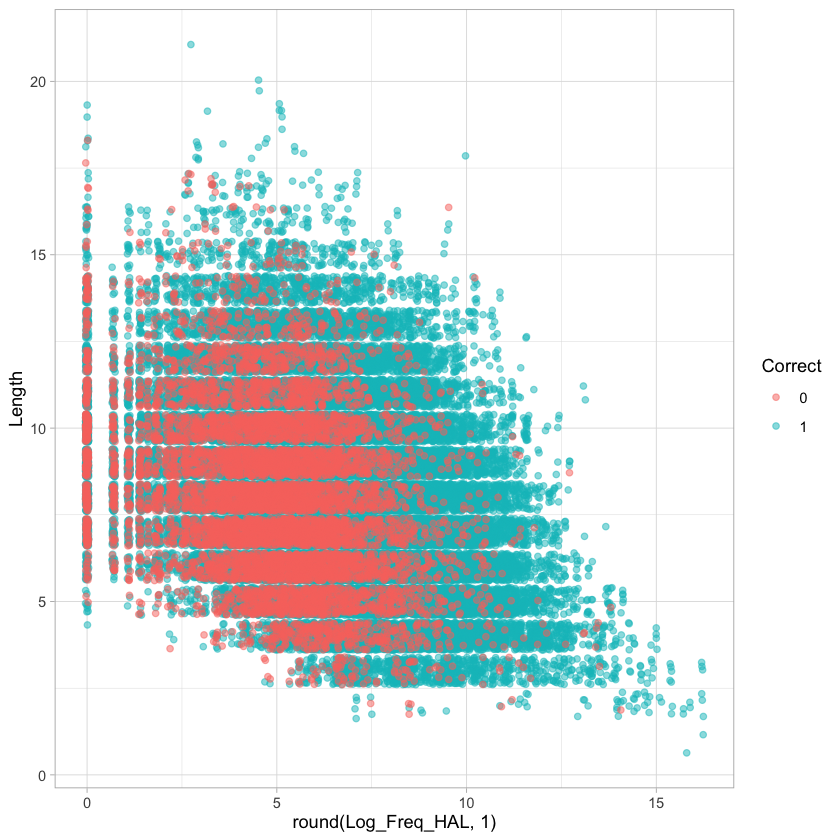

In [9]:
 # Load the tidyverse package, if you haven't yet
df$Correct <- as.factor(df$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(df,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

> *Write your reponse here*
> **assuming that 1 (blue) = correct and 0 (red) = incorrect
> Correct responses appear more common for words with higher log frequency. Word length appears to have a weaker relationship with correctness, with considerable overlap between correct and incorrect responses across different word lengths.  

---
## 3. Logistic Regression: Fitting the model (2 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [14]:
# WRITE YOUR CODE HERE

model1 <- glm(Correct ~ Length*Log_Freq_HAL, data = df, family = "binomial")

summary(model1)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = "binomial", 
    data = df)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> *Write your response here*
> There is a statistically significant interaction between word length and frequency, meaning the effect of word length on correctness depends on word frequency. The negative interaction indicates that word length matters less as word frequency increases. Both length and frequency have significant conditional effects on correctness.

---
## 4. Interpreting predictions from the model (3 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [19]:
# WRITE YOUR CODE HERE

prob_df <- data.frame(predict(model1, type = "response"))
colnames(prob_df) <- 'predicted_prob'

threshold <- 0.5
num_observations = nrow(prob_df)
prob_df$predicted_binary <- rep(0, num_observations)  
prob_df$predicted_binary[prob_df$predicted_prob > threshold] <- 1  


confusion_df <- data.frame(predicted = prob_df$predicted_binary, actual = df$Correct)
conf_matrix <- table(confusion_df)
print(conf_matrix)

accuracy <- mean(confusion_df$predicted == confusion_df$actual)
print(paste("Overall accuracy:", round(accuracy, 3)))



         actual
predicted     0     1
        0    13    44
        1  7966 62566
[1] "Overall accuracy: 0.887"


Did the model do well at predicting lexical decision correctness? Why or why not?

> *Write your response here*  
> The model correctly predicts responses ~89% of the time based on word length and frequency. However, the model produces more false positives than false negatives, and it appears to be heavily biased towards correct reponses. So, this model does well at predicting correct responses but not well at predicting incorrect responses. 

## 5. QDA (3 points)

Load in the `MASS` library and fit a QDA model to the data set. The predictors are still `Length`, `Log_Freq_HAL`, and their interaction, just like the logistic regression model you just ran, and the dependent variable is still `Correct`.

*Hint: see the Classifiers tutorial.*

In [20]:
# WRITE YOUR CODE HERE

library(MASS)

model_qda <- qda(Correct ~ Length*Log_Freq_HAL, data = df)
model_qda

Call:
qda(Correct ~ Length * Log_Freq_HAL, data = df)

Prior probabilities of groups:
        0         1 
0.1130346 0.8869654 

Group means:
    Length Log_Freq_HAL Length:Log_Freq_HAL
0 8.047124     4.932123            37.95260
1 7.979971     6.444849            49.34219

Now look at how well the predicted `Correct` values compare with actual `Correct` values for the whole data set. Output a confusion matrix and overall prediction accuracy.

In [21]:
# WRITE YOUR CODE HERE

df$Correct <- factor(df$Correct, levels = c(0, 1))

qda_pred <- predict(model_qda, df)$class

confusion_df <- data.frame(predicted = qda_pred, actual = df$Correct)
conf_matrix <- table(confusion_df)
print(conf_matrix)

accuracy <- mean(confusion_df$predicted == confusion_df$actual)
print(paste("Overall accuracy:", round(accuracy, 3)))

         actual
predicted     0     1
        0   455  1647
        1  7524 60963
[1] "Overall accuracy: 0.87"


How does QDA prediction performance differ from that of logistic regression?

> *Write your response here*
> Overall accuracy is similar but slightly lower than the logistic regression. QDA model is better at predicting incorrect responses but slightly worse at predicting correct responses. QDA is a slightly less biased model even though both models are still better at prediting correct responses. 

**DUE:** 5pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*